In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
df=pd.read_csv("Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

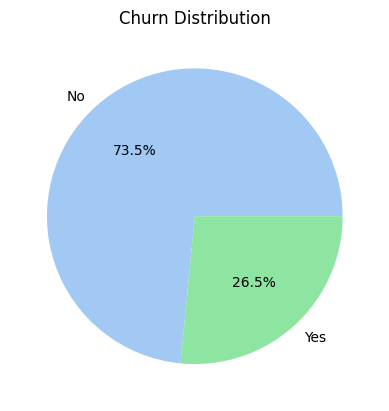

In [5]:
churn_counts=df["Churn"].value_counts()

colors=sns.color_palette("pastel6")


plt.pie(
    churn_counts,
    labels=churn_counts.index,
    colors=colors,
    autopct='%1.1f%%'
)
plt.title("Churn Distribution")
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [8]:
df["TotalCharges"].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [9]:
df[df["TotalCharges"].str.strip()==""][["customerID","TotalCharges"]]

,customerID,TotalCharges
488,4472-LVYGI,
753,3115-CZMZD,
936,5709-LVOEQ,
1082,4367-NUYAO,
1340,1371-DWPAZ,
3331,7644-OMVMY,
3826,3213-VVOLG,
4380,2520-SGTTA,
5218,2923-ARZLG,
6670,4075-WKNIU,


In [10]:
print("Before:",df["TotalCharges"].dtype)
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
print("After:",df["TotalCharges"].dtype)

Before: object
After: float64


In [11]:
# Önce NaN olan satırları gör
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)

In [13]:
df=df.drop("customerID",axis=1)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


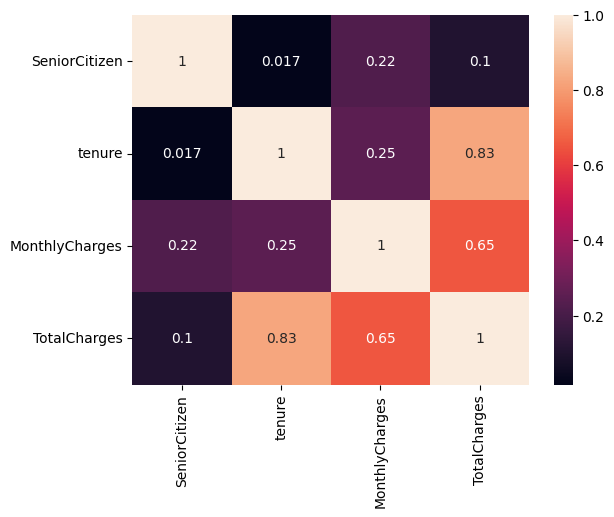

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [16]:
df.isnull().sum().sort_values(ascending=True)

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

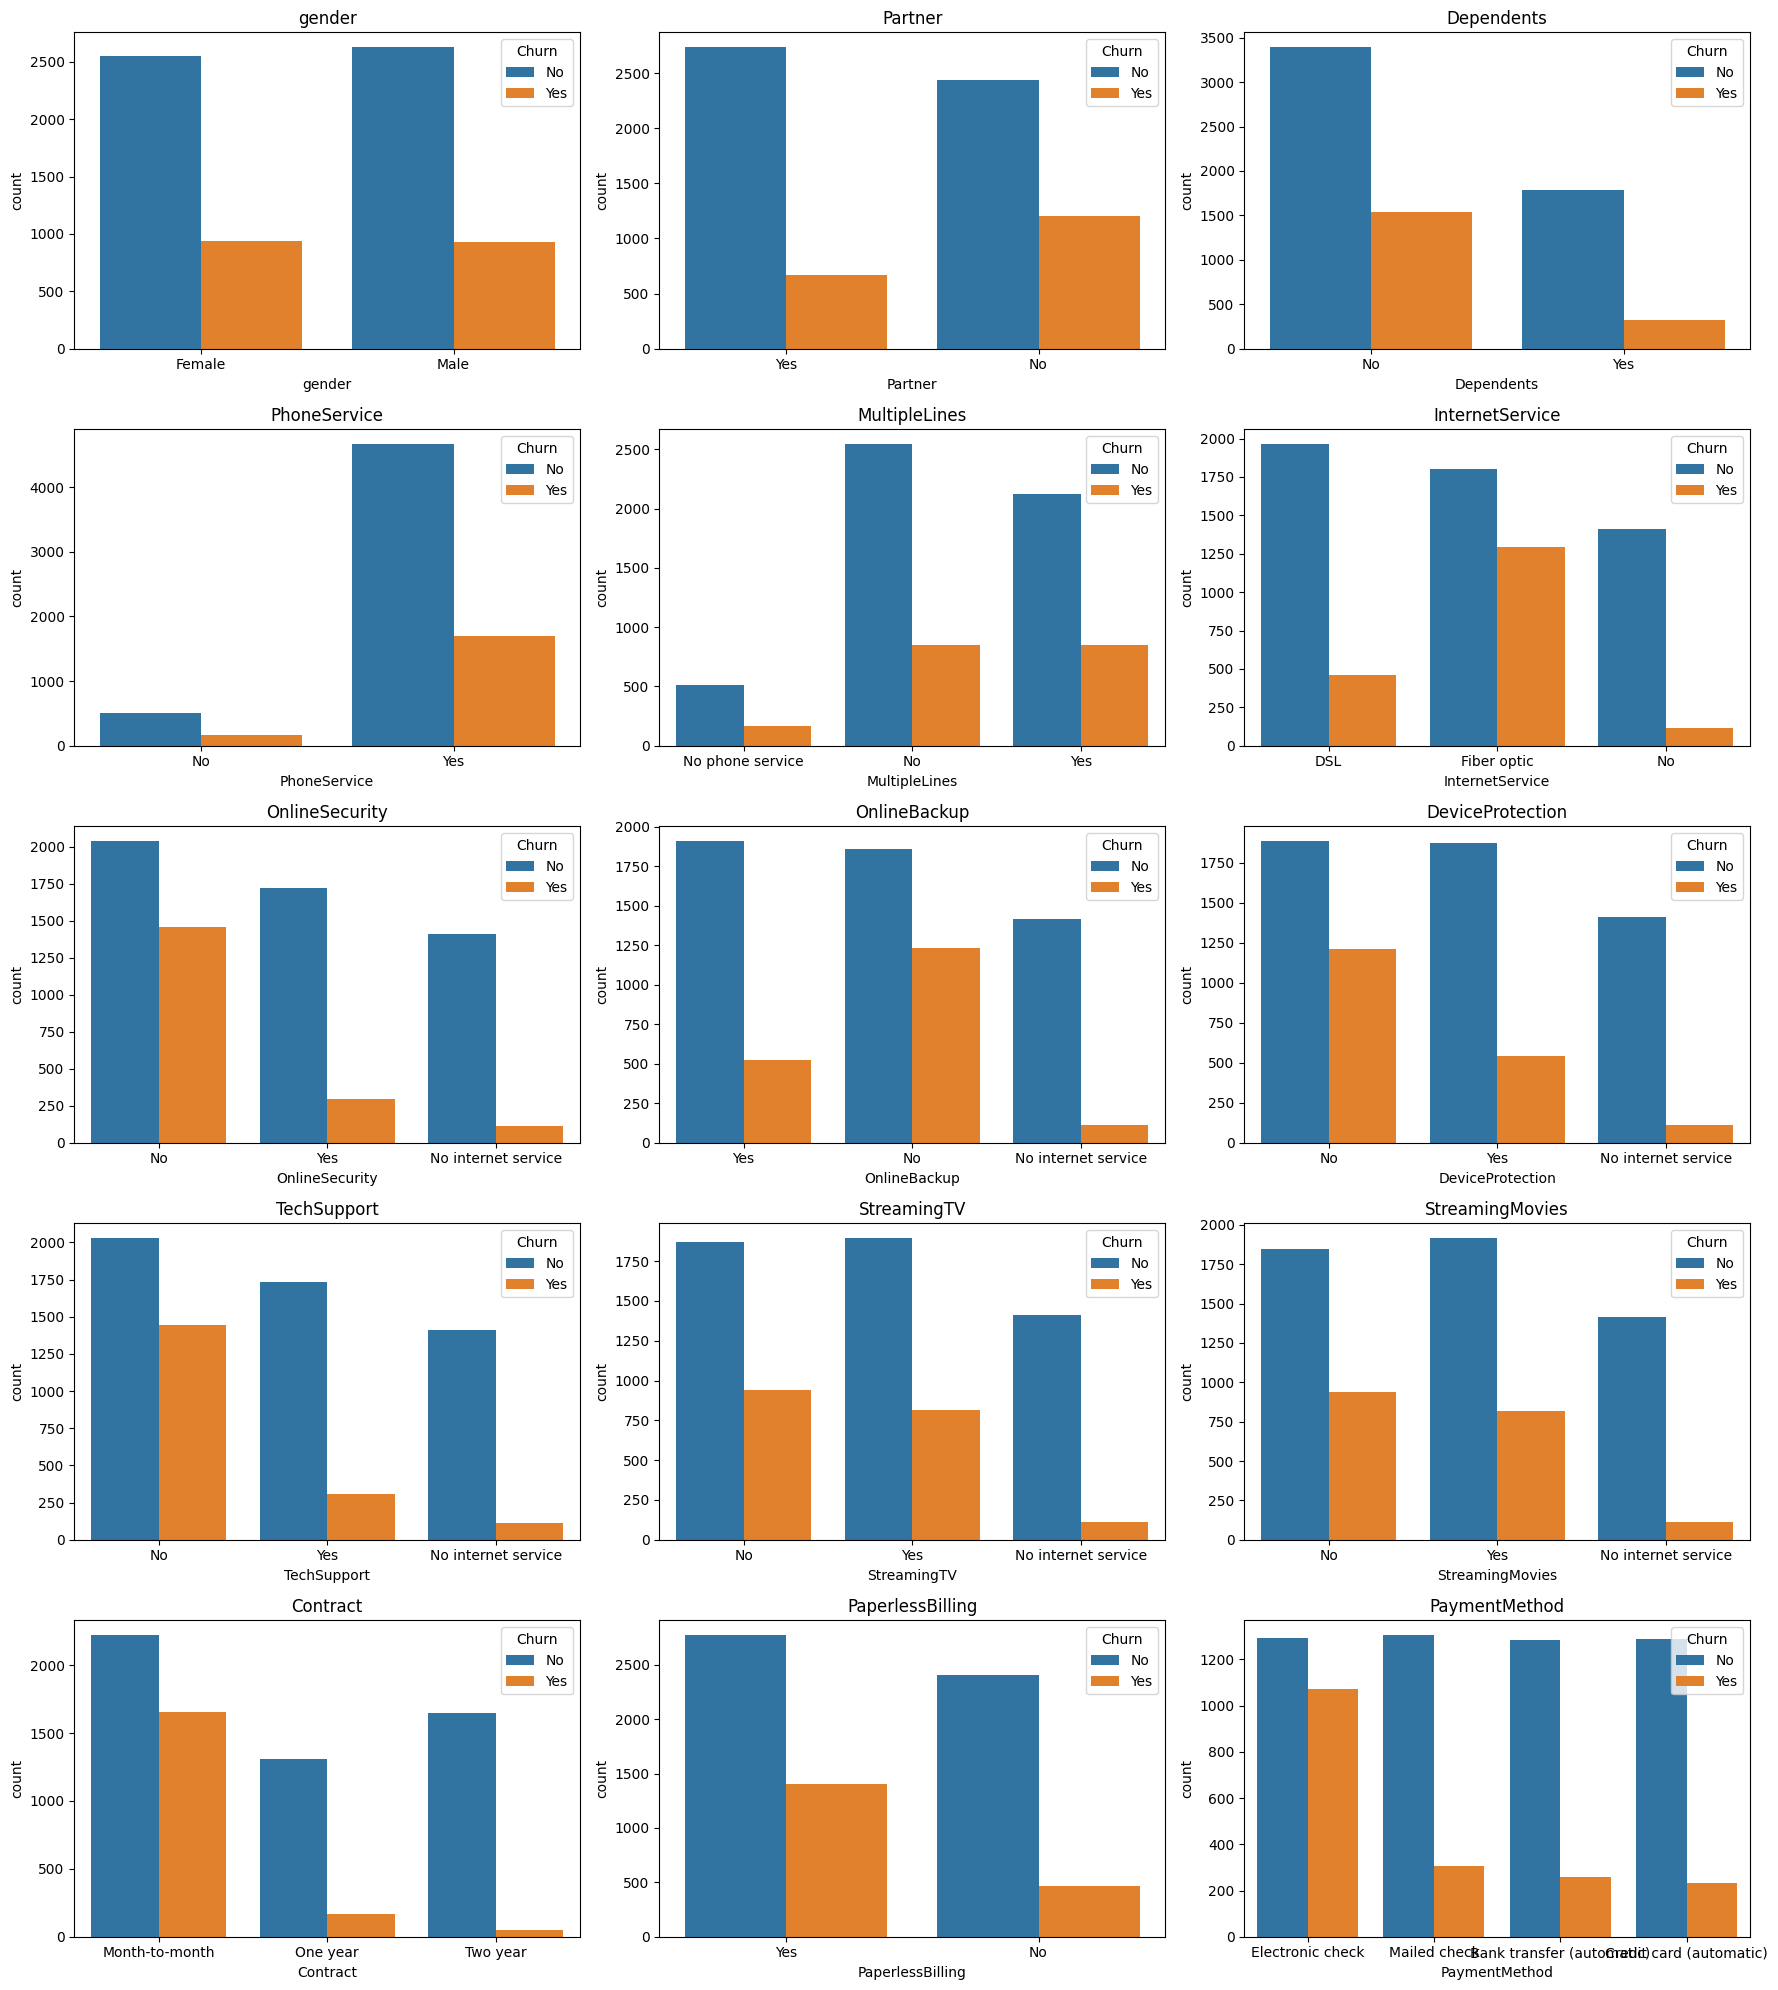

In [17]:
categorical_cols = df.select_dtypes(include='object').columns.drop('Churn')


fig,axes=plt.subplots(nrows=5,ncols=3,figsize=(18,20))
axes=axes.flatten()

for i,col in enumerate(categorical_cols):
    sns.countplot(data=df,x=col,hue='Churn',ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [18]:
for col in df.select_dtypes(include="object").columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("------------\n")

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64
------------

--- Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64
------------

--- Dependents ---
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
------------

--- PhoneService ---
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
------------

--- MultipleLines ---
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
------------

--- InternetService ---
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
------------

--- OnlineSecurity ---
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64
------------

--- OnlineBackup ---
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64
------------

--- DeviceProtect

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [20]:
binary_cols=["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

joblib.dump(label_encoders, 'models/label_encoders.pkl') 




['models/label_encoders.pkl']

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

nominal_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 
                'StreamingTV', 'StreamingMovies', 'PaymentMethod', 'Contract']

preprocessor=ColumnTransformer(transformers=[
    ("onehot",OneHotEncoder(drop='first',handle_unknown="ignore"),nominal_cols)
],
remainder='passthrough'
)

df_encoded=preprocessor.fit_transform(df)

joblib.dump(preprocessor, 'models/preprocessor.pkl')

['models/preprocessor.pkl']

In [22]:
# Yeni oluşan one-hot kolon isimlerini al
onehot_cols = preprocessor.named_transformers_['onehot'].get_feature_names_out(nominal_cols)

# remainder='passthrough' ile kalan kolonların isimlerini al (sırası korunur)
remainder_cols = [col for col in df.columns if col not in nominal_cols]

# Yeni kolon listesini birleştir
all_cols = list(onehot_cols) + remainder_cols

df_encoded = pd.DataFrame(df_encoded, columns=all_cols)

In [23]:
# SUPERVİSED MODEL SELECTİON

In [24]:
X=df_encoded.drop("Churn",axis=1)
y=df_encoded["Churn"]

joblib.dump(list(X.columns), 'models/feature_columns.pkl')

['models/feature_columns.pkl']

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [26]:
#Scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


joblib.dump(scaler, 'models/scaler_supervised.pkl')

['models/scaler_supervised.pkl']

In [27]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score

def calculate_model_metrics(true,predicted):
    acc=accuracy_score(true,predicted)
    cr=classification_report(true,predicted)
    cm=confusion_matrix(true,predicted)
    f1=f1_score(true,predicted)

    return acc,cr,cm,f1

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models={
    "Logistic Regression":LogisticRegression(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42),
    "SVC":SVC(random_state=42),
    "KNeighbors":KNeighborsClassifier(),
    "XGBoost":XGBClassifier(random_state=42),
    "LightGBM":LGBMClassifier(random_state=42)
}

results=[]
all_predictions={}

for name,model in models.items():
    model.fit(X_train_scaled,y_train)

    #prediction
    y_train_pred=model.predict(X_train_scaled)
    y_test_pred=model.predict(X_test_scaled)

    #claculate metric
    X_train_acc,X_train_cr,X_train_cm,X_train_f1=calculate_model_metrics(y_train,y_train_pred)
    X_test_acc,X_test_cr,X_test_cm,X_test_f1=calculate_model_metrics(y_test,y_test_pred)

    results.append({
        "Model":name,
        "Train_Accuracy":X_train_acc,"Test_Accuracy":X_test_acc,
        "Train_F1":X_train_f1,"Test_F1":X_test_f1
    })

    all_predictions[name]={"y_test_pred":y_test_pred,"confusion_matrix":X_test_cm}

    joblib.dump(model, f'models/{name.lower().replace(" ", "_")}.pkl')

results_df=pd.DataFrame(results)    


[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000614 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


c:\Users\VİCTUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\VİCTUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [29]:
results_df

,Model,Train_Accuracy,Test_Accuracy,Train_F1,Test_F1
0,Logistic Regression,0.806532,0.806955,0.602190,0.609195
1,Random Forest,0.998048,0.787083,0.996312,0.549550
2,Gradient Boosting,0.825169,0.797729,0.628722,0.570136
3,SVC,0.821619,0.792761,0.618885,0.556231
4,KNeighbors,0.834221,0.747339,0.671820,0.512329
5,XGBoost,0.930600,0.776437,0.864846,0.553191
6,LightGBM,0.880192,0.790632,0.757978,0.569343


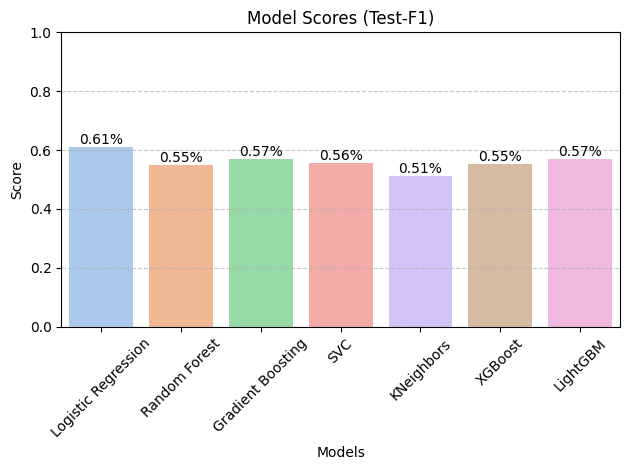

In [30]:
colors = sns.color_palette('pastel', n_colors=len(results_df))

plt.Figure(figsize=(10,6))
ax = sns.barplot(x='Model', y='Test_F1', data=results_df,hue='Model', palette=colors,legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Model Scores (Test-F1)')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [31]:
#HYPERPARAMETER TUNİNG (Logistic Regression,Gradient Boosting,SVC)

In [32]:
from sklearn.model_selection import GridSearchCV

tuning_configs = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=42),
        "params": {
            'C': [0.001, 0.01, 0.1, 1, 10, 100],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear']
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [2, 3, 4, 5],
            'subsample': [0.7, 0.8, 1.0]
        }
    },
    "SVC": {
        "model": SVC(random_state=42),
        "params": {
            'C': [0.1, 1, 10, 100],
            'gamma': ['scale', 'auto', 0.01, 0.1],
            'kernel': ['rbf', 'linear']
        }
    }
}

In [33]:
tuned_results = []
tuned_models = {} #ileride kaydetme,predict işlemlerinde kullanmak için 

for name, config in tuning_configs.items():
    print(f"\n{'='*50}\nTuning: {name}\n{'='*50}")
    
    grid_search = GridSearchCV(
        config["model"],
        config["params"],
        cv=5,
        scoring='f1',
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train_scaled, y_train)
    
    best_model = grid_search.best_estimator_
    tuned_models[name] = best_model

    # Test setinde tahmin
    y_train_pred = best_model.predict(X_train_scaled)
    y_test_pred = best_model.predict(X_test_scaled)
    
    train_acc, train_cr, train_cm, train_f1 = calculate_model_metrics(y_train, y_train_pred)
    test_acc, test_cr, test_cm, test_f1 = calculate_model_metrics(y_test, y_test_pred)
    
    tuned_results.append({
        "Model": name,
        "Best Params": grid_search.best_params_,
        "CV Best F1": grid_search.best_score_,
        "Train_F1": train_f1,
        "Test_F1": test_f1,
        "Test_Accuracy": test_acc
    })


Tuning: Logistic Regression
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tuning: Gradient Boosting
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Tuning: SVC
Fitting 5 folds for each of 32 candidates, totalling 160 fits


In [34]:
tuned_results_df = pd.DataFrame(tuned_results)
print(tuned_results_df)

                 Model                                        Best Params  \
0  Logistic Regression  {'C': 0.001, 'penalty': 'l2', 'solver': 'libli...   
1    Gradient Boosting  {'learning_rate': 0.05, 'max_depth': 2, 'n_est...   
2                  SVC         {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}   

   CV Best F1  Train_F1   Test_F1  Test_Accuracy  
0    0.630884  0.631982  0.619048       0.784244  
1    0.589373  0.615211  0.581325       0.802697  
2    0.587555  0.676353  0.556818       0.778566  


In [35]:
final_model = tuned_models["Logistic Regression"]
joblib.dump(final_model, 'models/best_model.pkl')

['models/best_model.pkl']

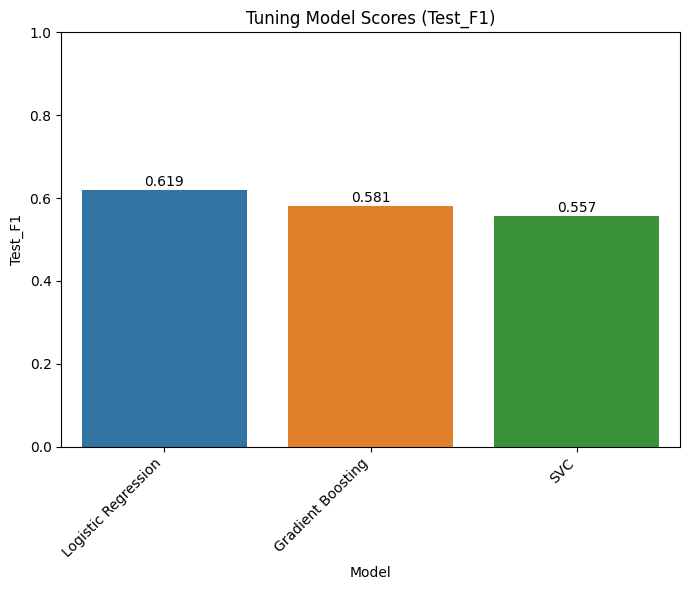

In [36]:
plt.figure(figsize=(7,6))

ax = sns.barplot(data=tuned_results_df, x='Model', y='Test_F1', hue='Model', legend=False)

plt.title("Tuning Model Scores (Test_F1)")
plt.ylabel("Test_F1")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')

for i, v in enumerate(tuned_results_df['Test_F1']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [37]:
X_cluster=df_encoded.drop("Churn",axis=1)
churn_for_analysis=df_encoded["Churn"]

In [38]:
scaler_cluster=StandardScaler()
X_cluster_scaled=scaler_cluster.fit_transform(X_cluster)

joblib.dump(scaler_cluster, 'models/scaler_clustering.pkl')

['models/scaler_clustering.pkl']

In [39]:
X_cluster_scaled

array([[ 3.05401039, -0.85417615, -0.88565976, ...,  0.8297975 ,
        -1.16032292, -0.99261052],
       [-0.32743831, -0.85417615, -0.88565976, ..., -1.20511329,
        -0.25962894, -0.17216471],
       [-0.32743831, -0.85417615, -0.88565976, ...,  0.8297975 ,
        -0.36266036, -0.9580659 ],
       ...,
       [ 3.05401039, -0.85417615, -0.88565976, ...,  0.8297975 ,
        -1.1686319 , -0.85293201],
       [-0.32743831,  1.17071871,  1.12910177, ...,  0.8297975 ,
         0.32033821, -0.87051315],
       [-0.32743831, -0.85417615,  1.12910177, ...,  0.8297975 ,
         1.35896134,  2.01389665]], shape=(7043, 30))

In [40]:
#PCA
from sklearn.decomposition import PCA

pca=PCA()

In [41]:
pca_cluster=pd.DataFrame(pca.fit_transform(X_cluster_scaled))

In [42]:
#Amaç boyut indirgemek ama hala aynı sayıda kolon var 
pca_cluster.shape

(7043, 30)

In [43]:
pca.explained_variance_

array([9.95533947e+00, 3.59566595e+00, 2.70694051e+00, 1.42574372e+00,
       1.24403851e+00, 1.23608770e+00, 1.14375092e+00, 1.00115535e+00,
       9.36278074e-01, 8.85920816e-01, 7.98151280e-01, 7.13542101e-01,
       6.74687160e-01, 6.16850269e-01, 6.06827104e-01, 5.26058639e-01,
       4.66691380e-01, 4.57372726e-01, 4.39983666e-01, 2.76931389e-01,
       2.37661941e-01, 5.76833439e-02, 8.98134501e-04, 1.83461873e-16,
       9.64545491e-17, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00])

In [44]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Kaç bileşen %90'ı, %95'i geçiyor, net olarak bul
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"%90 varyans için gereken bileşen sayısı: {n_components_90}")
print(f"%95 varyans için gereken bileşen sayısı: {n_components_95}")

%90 varyans için gereken bileşen sayısı: 15
%95 varyans için gereken bileşen sayısı: 17


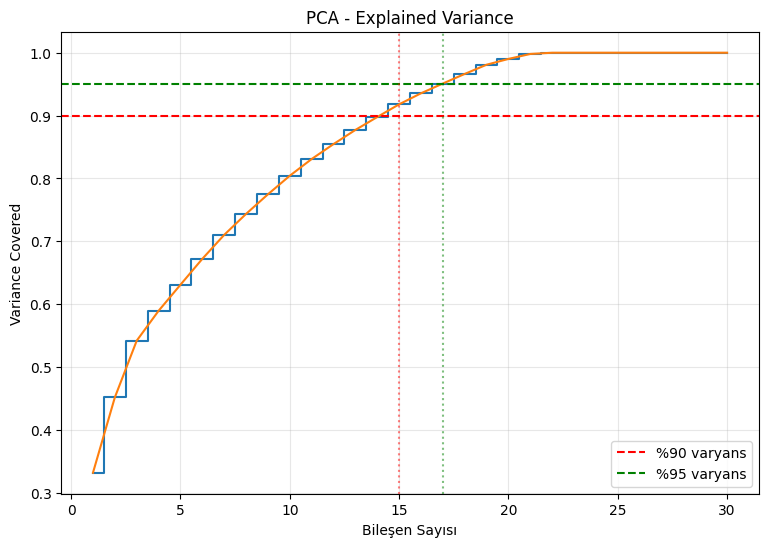

In [45]:
plt.figure(figsize=(9,6))
plt.step(range(1, 31), cumulative_variance, where='mid')
plt.plot(range(1, 31), cumulative_variance)

plt.axhline(y=0.90, color='r', linestyle='--', label='%90 varyans')
plt.axhline(y=0.95, color='g', linestyle='--', label='%95 varyans')
plt.axvline(x=n_components_90, color='r', linestyle=':', alpha=0.5)
plt.axvline(x=n_components_95, color='g', linestyle=':', alpha=0.5)

plt.xlabel('Bileşen Sayısı')
plt.ylabel('Variance Covered')
plt.title('PCA - Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
pca_final=PCA(n_components=15,random_state=42)
X_pca_final=pca_final.fit_transform(X_cluster_scaled)

print("Yeni shape:", X_pca_final.shape)

joblib.dump(pca_final, 'models/pca_clustering.pkl')

Yeni shape: (7043, 15)


['models/pca_clustering.pkl']

In [47]:
from sklearn.cluster import KMeans

wcss=[]
for k in range(1,16):
    kmeans=KMeans(n_clusters=k)
    kmeans.fit(X_pca_final)
    wcss.append(kmeans.inertia_)

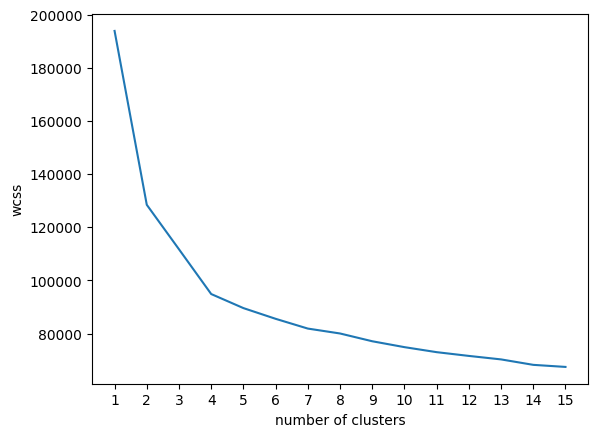

In [48]:
plt.plot(range(1,16),wcss)
plt.xticks(range(1,16))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [49]:
kmeans=KMeans(n_clusters=4,random_state=42)
model=kmeans.fit(X_pca_final)

cluster_label=model.labels_

df["Cluster"]=cluster_label

In [50]:
df["Cluster"].value_counts()

Cluster
1    2741
3    2094
2    1526
0     682
Name: count, dtype: int64

In [51]:
from sklearn.metrics import silhouette_score,davies_bouldin_score, calinski_harabasz_score
sill_score=silhouette_score(X_pca_final,cluster_label)
db_score=davies_bouldin_score(X_pca_final,cluster_label)
ch_score=calinski_harabasz_score(X_pca_final,cluster_label)

print("KMEANS")
print(f"Silhoutte Score:{sill_score:.4f}")
print(f"Davies-Bouldin Score: {db_score:.4f}") 
print(f"Calinski-Harabasz Score: {ch_score:.4f}")


KMEANS
Silhoutte Score:0.2621
Davies-Bouldin Score: 1.5799
Calinski-Harabasz Score: 2450.1452


In [52]:
clustering_results = []
clustering_results.append({
    'Algorithm': 'KMeans',
    'Silhouette': sill_score,
    'Davies-Bouldin': db_score,
    'Calinski-Harabasz': ch_score
})

In [53]:
joblib.dump(kmeans, 'models/kmeans_model.pkl')

['models/kmeans_model.pkl']

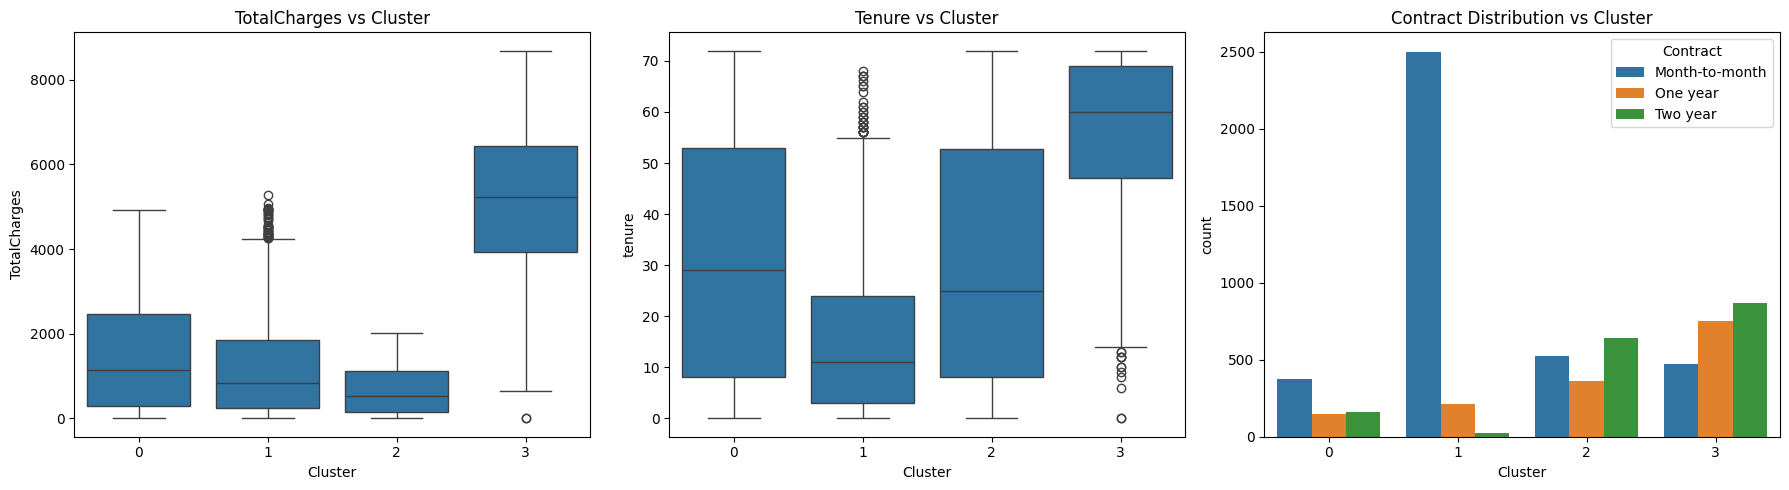

In [54]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18,5))

sns.boxplot(data=df, x="Cluster", y="TotalCharges", ax=axes[0])
axes[0].set_title("TotalCharges vs Cluster")

sns.boxplot(data=df, x="Cluster", y="tenure", ax=axes[1])
axes[1].set_title("Tenure vs Cluster")

sns.countplot(data=df, x="Cluster", hue="Contract", ax=axes[2])
axes[2].set_title("Contract Distribution vs Cluster")

plt.tight_layout()
plt.savefig('reports/cluster_profiles.png', dpi=150)
plt.show()

In [55]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN()

eps_values = np.arange(1.0, 10.0, 0.5)   # PCA(15 boyut) verisi için daha geniş aralık
min_sample_values = [5, 10, 15, 20]

db_results = []

for eps in eps_values:
    for min_sample in min_sample_values:
        db = DBSCAN(eps=eps, min_samples=min_sample).fit(X_pca_final)
        labels = db.labels_
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        # en az 2 gerçek cluster olmalı, hesaplanabilir olsun
        if n_clusters < 2:
            continue
        
        mask = labels != -1
        silhouette = silhouette_score(X_pca_final[mask], labels[mask])
        
        db_results.append({
            "eps": eps,
            "min_samples": min_sample,
            "silhouette_score": silhouette,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio
        })

db_results_df = pd.DataFrame(db_results)
db_results_df = db_results_df.sort_values(by="silhouette_score", ascending=False)
print(db_results_df.head(10))

    eps  min_samples  silhouette_score  n_clusters  noise_ratio
3   1.0           20          0.820227          19     0.916939
2   1.0           15          0.805231          27     0.896919
1   1.0           10          0.787082          55     0.849638
0   1.0            5          0.738662         185     0.725543
40  6.0            5          0.364106           2     0.000000
41  6.0           10          0.364106           2     0.000000
42  6.0           15          0.364106           2     0.000000
43  6.0           20          0.364106           2     0.000000
39  5.5           20          0.364106           2     0.000000
38  5.5           15          0.364106           2     0.000000


In [56]:
filtered = db_results_df[
    (db_results_df['noise_ratio'] >= 0.05) & (db_results_df['noise_ratio'] <= 0.40) &
    (db_results_df['n_clusters'] >= 3) & (db_results_df['n_clusters'] <= 8)
]
filtered = filtered.sort_values(by='silhouette_score', ascending=False)
print(filtered.head(10))

    eps  min_samples  silhouette_score  n_clusters  noise_ratio
15  2.5           20          0.352145           3     0.361494
19  3.0           20          0.284204           4     0.096408
18  3.0           15          0.280241           4     0.057078
14  2.5           15          0.237537           5     0.314639


In [57]:
final_dbscan=DBSCAN(eps=3,min_samples=15)
dbscan_final=final_dbscan.fit(X_pca_final)

dbscan_final_label=dbscan_final.labels_

n_clusters = len(set(dbscan_final_label)) - (1 if -1 in dbscan_final_label else 0)
n_noise = list(dbscan_final_label).count(-1)

# df'e ekle
df['DBSCAN_Cluster'] = dbscan_final_label

joblib.dump(final_dbscan, 'models/dbscan_model.pkl')

['models/dbscan_model.pkl']

In [58]:
mask = dbscan_final_label != -1
sil = silhouette_score(X_pca_final[mask], dbscan_final_label[mask])
db = davies_bouldin_score(X_pca_final[mask], dbscan_final_label[mask])
ch = calinski_harabasz_score(X_pca_final[mask], dbscan_final_label[mask])
noise_ratio_db = n_noise / len(dbscan_final_label)
print("DBSCAN")
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.4f}")
print(f"Cluster sayısı: {n_clusters}")
print(f"Noise sayısı: {noise_ratio_db}")

DBSCAN
Silhouette Score: 0.2802
Davies-Bouldin Score: 1.2949
Calinski-Harabasz Score: 1697.2497
Cluster sayısı: 4
Noise sayısı: 0.05707794973732784


In [59]:
from sklearn.cluster import HDBSCAN

In [60]:
min_cluster_size_values = [5, 10, 20, 30, 50, 75, 100, 150]
min_sample_values = [None, 5, 10, 15, 20, 30, 50]

hdb_results = []

for min_cluster_size in min_cluster_size_values:
    for min_sample in min_sample_values:

        hdb = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_sample
        )

        labels = hdb.fit_predict(X_pca_final)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)

        # En az 2 gerçek cluster olmalı
        if n_clusters < 2:
            continue

        mask = labels != -1

        # Noise çıkarıldıktan sonra yeterli örnek var mı?
        if mask.sum() < 2:
            continue

        silhouette = silhouette_score(
            X_pca_final[mask],
            labels[mask]
        )

        hdb_results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_sample,
            "silhouette_score": silhouette,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio
        })

hdb_results_df = pd.DataFrame(hdb_results)

hdb_results_df = hdb_results_df.sort_values(
    by="silhouette_score",
    ascending=False
)

print(hdb_results_df.head(10))

    min_cluster_size  min_samples  silhouette_score  n_clusters  noise_ratio
0                  5          NaN          0.408819         293     0.479483
1                  5          5.0          0.408819         293     0.479483
2                  5         10.0          0.396492         112     0.608973
7                 10          NaN          0.389339          99     0.614085
9                 10         10.0          0.389339          99     0.614085
3                  5         15.0          0.383621          64     0.669317
10                10         15.0          0.357464          56     0.656254
39                75         20.0          0.314979           3     0.000000
43               100          5.0          0.314979           3     0.000000
46               100         20.0          0.314979           3     0.000000


In [61]:
hdb_results_df[hdb_results_df["noise_ratio"]<0.30].sort_values(by="silhouette_score",ascending=False).head(10)

,min_cluster_size,min_samples,silhouette_score,n_clusters,noise_ratio
39,75,20.0,0.314979,3,0.0
43,100,5.0,0.314979,3,0.0
46,100,20.0,0.314979,3,0.0
45,100,15.0,0.314979,3,0.0
44,100,10.0,0.314979,3,0.0
52,150,15.0,0.314979,3,0.0
53,150,20.0,0.314979,3,0.0
50,150,5.0,0.314979,3,0.0
51,150,10.0,0.314979,3,0.0
38,75,15.0,0.314979,3,0.0


In [62]:
best_hdbscan=HDBSCAN(min_samples=100,min_cluster_size=5)
hdb_labels = best_hdbscan.fit_predict(X_pca_final)


In [63]:
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)

n_noise_hdb = (hdb_labels == -1).sum()

noise_ratio = n_noise_hdb / len(hdb_labels)

mask = hdb_labels != -1

sil_hdb = silhouette_score(X_pca_final[mask], hdb_labels[mask])
db_hdb = davies_bouldin_score(X_pca_final[mask], hdb_labels[mask])
ch_hdb = calinski_harabasz_score(X_pca_final[mask], hdb_labels[mask])

print("HDBSCAN")
print("Silhouette:", silhouette)
print("Cluster sayısı:", n_clusters)
print("Noise oranı:", noise_ratio)
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.4f}")

HDBSCAN
Silhouette: 0.3145646167413656
Cluster sayısı: 3
Noise oranı: 0.029532869515831322
Davies-Bouldin Score: 1.2949
Calinski-Harabasz Score: 1697.2497


In [64]:
comparison_df = pd.DataFrame({
    "Model": [
        "KMeans",
        "DBSCAN",
        "HDBSCAN"
    ],

    "Silhouette Score": [
        sill_score,
        sil,
        sil_hdb
    ],

    "Davies-Bouldin Score": [
        db_score,
        db,
        db_hdb
    ],

    "Calinski-Harabasz Score": [
        ch_score,
        ch,
        ch_hdb
    ],

    "Noise Oranı": [
        0,
        noise_ratio_db,
        noise_ratio
    ]
})

In [65]:
comparison_df

,Model,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score,Noise Oranı
0,KMeans,0.262091,1.579920,2450.145173,0.000000
1,DBSCAN,0.280241,1.294943,1697.249667,0.057078
2,HDBSCAN,0.312157,1.298633,2474.379277,0.029533


In [66]:
df["Cluster"].head()

0    0
1    1
2    1
3    0
4    1
Name: Cluster, dtype: int32

In [67]:
cluster_profile=df.groupby("Cluster").agg(
    customer_count=("Cluster","size"),
    avg_tenure=("tenure", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean"),
    avg_total_charges=("TotalCharges", "mean")
)

cluster_profile


,customer_count,avg_tenure,avg_monthly_charges,avg_total_charges
Cluster,,,,
0,682,31.737537,42.028592,1496.033651
1,2741,15.619117,74.007096,1178.974863
2,1526,30.547182,21.079194,662.604784
3,2094,55.834766,91.897230,5154.330826


### SHAP Analizi — Model Yorumlanabilirliği

En iyi model olarak seçilen **Logistic Regression (tuned)** modelinin tahminlerini SHAP (SHapley Additive exPlanations) ile yorumluyoruz. Bu analiz, hangi özelliklerin churn tahminini ne yönde etkilediğini gösterir.

In [68]:
import shap

explainer = shap.Explainer(final_model, X_train_scaled, feature_names=list(X.columns))
shap_values = explainer(X_test_scaled)


c:\Users\VİCTUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


### Global Özellik Önem Sırası (Bar Plot)

Modelin genel olarak hangi değişkenlere en çok önem verdiğini gösterir.

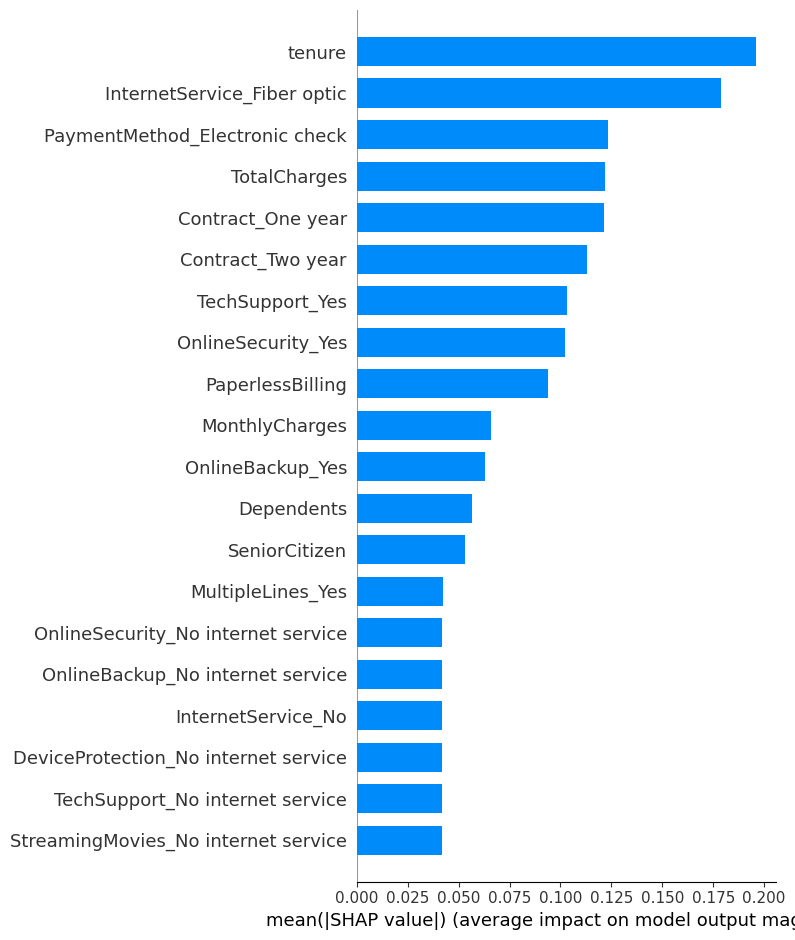

In [69]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=list(X.columns), plot_type='bar', show=True)


### Beeswarm Plot — Özelliklerin Yön ve Etki Büyüklüğü

Her noktanın rengi özelliğin değerini (kırmızı=yüksek, mavi=düşük), x ekseni ise churn tahminine katkısını gösterir.

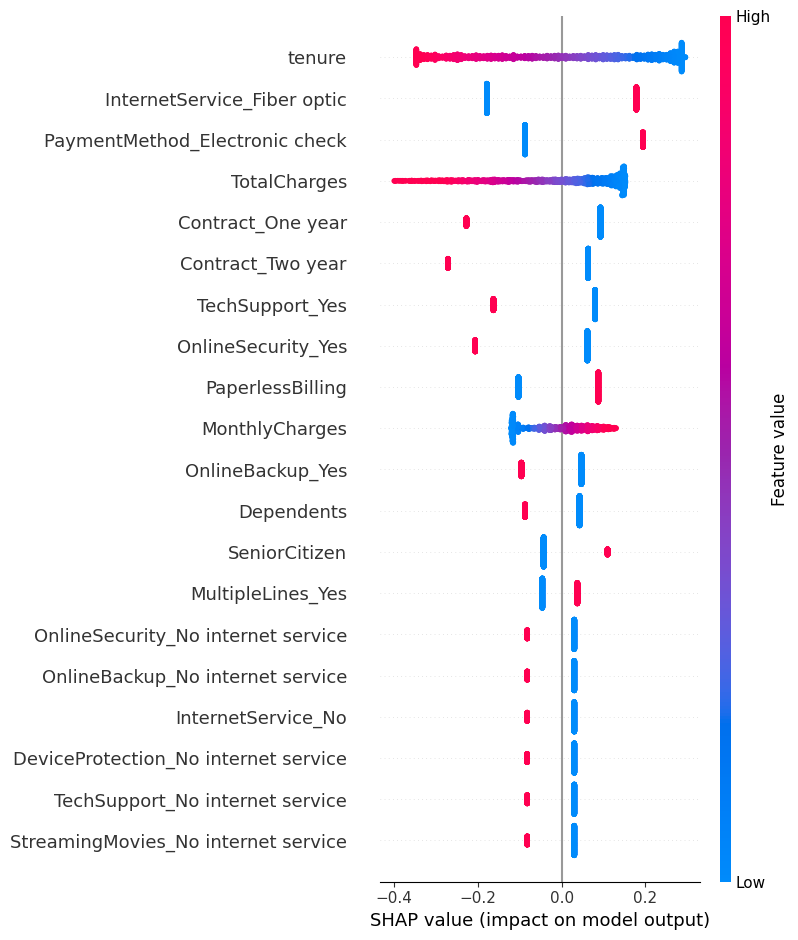

In [70]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=list(X.columns), show=True)


### Tekil Müşteri Açıklaması (Waterfall Plot)

Test setinden örnek bir müşterinin churn tahminine hangi özelliklerin ne kadar katkı sağladığını gösterir — model kararlarını müşteri bazında açıklamak için kullanılır.

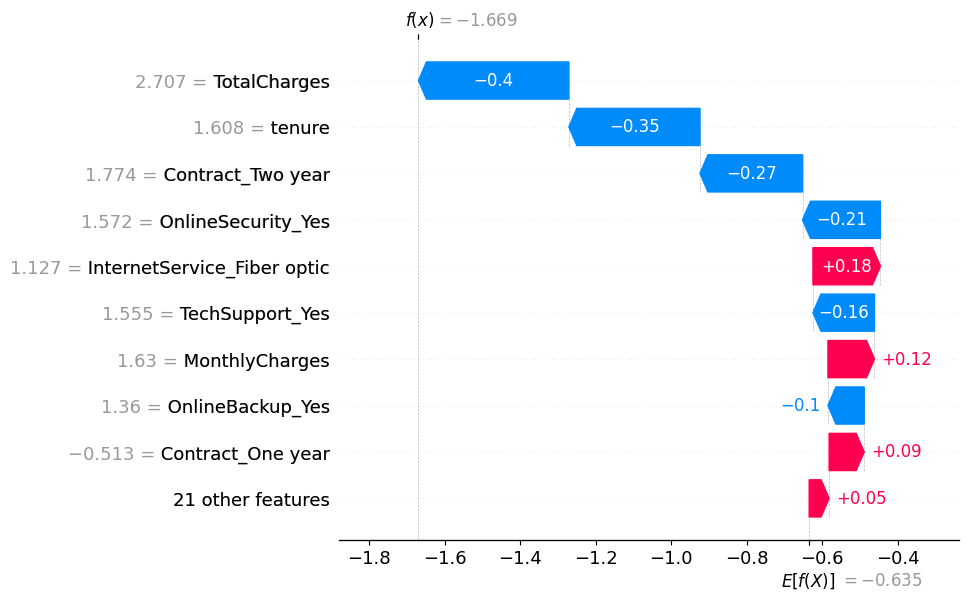

In [71]:
sample_idx = 0
shap.plots.waterfall(shap_values[sample_idx], show=True)


### SHAP Değerlerinin Kaydedilmesi

İleride tekrar kullanmak veya API/servis içinde açıklama üretmek için SHAP explainer'ı diske kaydediyoruz.

In [72]:
joblib.dump(explainer, 'models/shap_explainer.pkl')


['models/shap_explainer.pkl']